# 03 Carry Strategies

**Book:** *Expected Returns* (Ilmanen)  
**Focus:** Build a practical cross-asset carry proxy panel from local parquet data and test basic forward-return linkages.

## Local Data Scope (Important)

This scaffold is intentionally constrained to local `data/market_data` coverage.

- We **do not** have a full foreign short-rate panel, so classic FX carry (interest-rate differentials by currency pair) is not directly implementable here.
- We **do not** have futures curve strips by contract month, so commodity roll-yield carry is not directly implementable.
- We therefore use three carry-style proxies we can compute now:
  1. Treasury curve carry proxy: `T10Y2Y` (term slope)
  2. Credit spread carry proxy: `BAMLH0A0HYM2` (HY spread compensation)
  3. Vol term-structure carry proxy: `VIX3M - VIX` (contango/backwardation state)

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-29_expected_returns_ilmanen"
if str(STUDY_DIR) not in sys.path:
    sys.path.insert(0, str(STUDY_DIR))

from local_parquet import (
    DEFAULT_START,
    DEFAULT_END,
    business_days,
    load_fred_series,
    load_named_price_series,
    load_price_series,
    forward_return,
    rolling_zscore,
)

START = DEFAULT_START
END = DEFAULT_END
CARRY_PANEL_CSV = STUDY_DIR / "03_carry_proxy_panel.csv"
SUMMARY_CSV = STUDY_DIR / "03_carry_forward_summary.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Expected env: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Study dir:", STUDY_DIR)
print("Date window:", START, "to", END)

Expected env: conda activate ibkr-analytics && export PYTHONPATH=.
Study dir: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen
Date window: 2024-02-26 to 2026-02-27


In [2]:
fred = load_fred_series(["T10Y2Y", "BAMLH0A0HYM2", "SOFR"]).sort_index()
vix = load_named_price_series("vix_daily", value_col="close", start=START, end=END).rename("vix")
vix3m = load_named_price_series("vix3m_daily", value_col="close", start=START, end=END).rename("vix3m")

price_panel = load_price_series(["SPY", "DX-Y.NYB", "CL=F", "GC=F"], start=START, end=END)

idx = business_days(START, END)
base = pd.concat([fred, vix, vix3m], axis=1).reindex(idx).ffill()
base.index.name = "date"
price_panel = price_panel.reindex(idx).ffill()
price_panel.index.name = "date"

print("Base rows:", len(base), "Price rows:", len(price_panel))
base.tail()

Base rows: 525 Price rows: 525


            BAMLH0A0HYM2  SOFR  T10Y2Y        vix      vix3m
date                                                        
2026-02-23          2.95  3.66    0.60  21.010000  22.139999
2026-02-24          2.97  3.67    0.61  19.549999  21.340000
2026-02-25          2.94  3.67    0.60  17.930000  20.360001
2026-02-26          2.98  3.67    0.60  18.629999  20.809999
2026-02-27          2.98  3.67    0.59  19.860001  21.559999

In [3]:
carry = pd.DataFrame(index=base.index)

# Term slope as a stylized bond carry proxy (steeper curve = more roll-down cushion).
carry["treasury_curve_carry"] = base["T10Y2Y"] / 100.0

# HY spread level as compensation proxy for bearing credit risk.
carry["credit_spread_carry"] = base["BAMLH0A0HYM2"] / 100.0

# Vol carry proxy: positive when term structure is in contango.
carry["vol_term_carry"] = (base["vix3m"] - base["vix"]) / 100.0

for col in ["treasury_curve_carry", "credit_spread_carry", "vol_term_carry"]:
    carry[f"{col}_z"] = rolling_zscore(carry[col], window=252, min_periods=90)

targets = pd.DataFrame(index=price_panel.index)
for ticker, name in [("SPY", "spy"), ("DX-Y.NYB", "dxy"), ("CL=F", "wti"), ("GC=F", "gold")]:
    targets[f"{name}_fwd_21d"] = forward_return(price_panel[ticker], horizon=21)

carry_panel = carry.join(targets, how="inner").dropna()
carry_panel.tail()

            treasury_curve_carry  credit_spread_carry  vol_term_carry  treasury_curve_carry_z  credit_spread_carry_z  vol_term_carry_z  spy_fwd_21d  dxy_fwd_21d  wti_fwd_21d  gold_fwd_21d
date                                                                                                                                                                                       
2026-01-23                0.0064               0.0268          0.0306                1.085716              -1.012148          0.557253    -0.009924     0.001025     0.085803      0.045919
2026-01-26                0.0066               0.0269          0.0292                1.245417              -0.986308          0.485425    -0.007766     0.008656     0.082467      0.014981
2026-01-27                0.0071               0.0271          0.0287                1.657048              -0.934150          0.458433    -0.003364     0.015381     0.048565      0.024902
2026-01-28                0.0070               0.0272       

## FX Carry Feasibility From Local Parquet

A true FX carry implementation needs **currency-specific short rates** so each pair can be ranked by interest-rate differential.

The current local parquet lake contains:

- FX spot prices in `data/market_data/prices/fx.parquet`
- US-only FRED rates such as `DGS3MO` and `SOFR` in `data/market_data/fred/treasury_yields.parquet`

It does **not** contain non-USD short-rate series in parquet, so classic FX carry cannot be computed honestly under the current constraint set. The notebook therefore adds a **USD short-rate regime overlay** on available FX forward returns instead of fabricating true FX carry differentials.


In [4]:
FX_OVERLAY_CSV = STUDY_DIR / "03_fx_usd_rate_overlay.csv"
FX_OVERLAY_SUMMARY_CSV = STUDY_DIR / "03_fx_usd_rate_overlay_summary.csv"

fx_pairs = [
    "AUDUSD=X",
    "EURUSD=X",
    "GBPUSD=X",
    "NZDUSD=X",
    "USDCAD=X",
    "USDCHF=X",
    "USDJPY=X",
    "USDNOK=X",
    "USDSEK=X",
]

usd_rate_panel = load_fred_series(["DGS3MO", "SOFR"], start=START, end=END).reindex(idx).ffill()
fx_price_panel = load_price_series(fx_pairs, start=START, end=END).reindex(idx).ffill()

fx_forward = pd.DataFrame(index=fx_price_panel.index)
for pair in fx_pairs:
    fx_forward[f"{pair}_fwd_21d"] = forward_return(fx_price_panel[pair], horizon=21)

fx_overlay = pd.concat(
    [
        (usd_rate_panel["DGS3MO"] / 100.0).rename("usd_3m_yield"),
        (usd_rate_panel["SOFR"] / 100.0).rename("usd_sofr"),
        fx_forward,
    ],
    axis=1,
).dropna().copy()
fx_overlay["usd_3m_yield_z252"] = rolling_zscore(fx_overlay["usd_3m_yield"], window=252, min_periods=90)

overlay_rows = []
for pair in fx_pairs:
    col = f"{pair}_fwd_21d"
    sub = fx_overlay[["usd_3m_yield", col]].dropna().copy()
    sub["usd_rate_quintile"] = pd.qcut(sub["usd_3m_yield"], q=5, labels=False, duplicates="drop")
    grouped = sub.groupby("usd_rate_quintile", observed=True)[col].mean().rename("mean_fwd_return")
    out = grouped.to_frame().reset_index()
    out["pair"] = pair
    overlay_rows.append(out)

fx_overlay_summary = pd.concat(overlay_rows, ignore_index=True)
fx_corr = fx_overlay[["usd_3m_yield_z252", *[f"{pair}_fwd_21d" for pair in fx_pairs]]].corr().round(3)

print("True FX carry available from current local parquet:", False)
print("Only USD short-rate series are present in parquet, so the table below is a USD-rate regime overlay, not FX carry.")
fx_overlay.to_csv(FX_OVERLAY_CSV)
fx_overlay_summary.to_csv(FX_OVERLAY_SUMMARY_CSV, index=False)
fx_corr.loc[["usd_3m_yield_z252"], [f"{pair}_fwd_21d" for pair in fx_pairs]]


True FX carry available from current local parquet: False
Only USD short-rate series are present in parquet, so the table below is a USD-rate regime overlay, not FX carry.


                   AUDUSD=X_fwd_21d  EURUSD=X_fwd_21d  GBPUSD=X_fwd_21d  NZDUSD=X_fwd_21d  USDCAD=X_fwd_21d  USDCHF=X_fwd_21d  USDJPY=X_fwd_21d  USDNOK=X_fwd_21d  USDSEK=X_fwd_21d
usd_3m_yield_z252             0.032             0.375              0.18             0.063            -0.153            -0.335             -0.34            -0.199            -0.215

In [5]:
corr_matrix = carry_panel.corr().round(3)

def bucket_summary(panel: pd.DataFrame, signal_col: str, target_col: str):
    sub = panel[[signal_col, target_col]].dropna().copy()
    sub["bucket"] = pd.qcut(sub[signal_col], q=5, labels=False, duplicates="drop")
    grouped = sub.groupby("bucket", observed=True)[target_col].mean().rename("mean_fwd_return")
    out = grouped.to_frame()
    out["signal"] = signal_col
    out["target"] = target_col
    return out.reset_index()

summaries = []
for sig in ["treasury_curve_carry_z", "credit_spread_carry_z", "vol_term_carry_z"]:
    for tgt in ["spy_fwd_21d", "dxy_fwd_21d", "wti_fwd_21d", "gold_fwd_21d"]:
        summaries.append(bucket_summary(carry_panel, sig, tgt))

summary_df = pd.concat(summaries, ignore_index=True)
corr_matrix.loc[["treasury_curve_carry_z", "credit_spread_carry_z", "vol_term_carry_z"], ["spy_fwd_21d", "dxy_fwd_21d", "wti_fwd_21d", "gold_fwd_21d"]]

                        spy_fwd_21d  dxy_fwd_21d  wti_fwd_21d  gold_fwd_21d
treasury_curve_carry_z        0.303        0.105        0.044         0.021
credit_spread_carry_z         0.418       -0.275       -0.081         0.113
vol_term_carry_z             -0.240        0.211        0.188         0.000

Saved carry panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/03_carry_proxy_panel.csv
Saved bucket summary to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/03_carry_forward_summary.csv


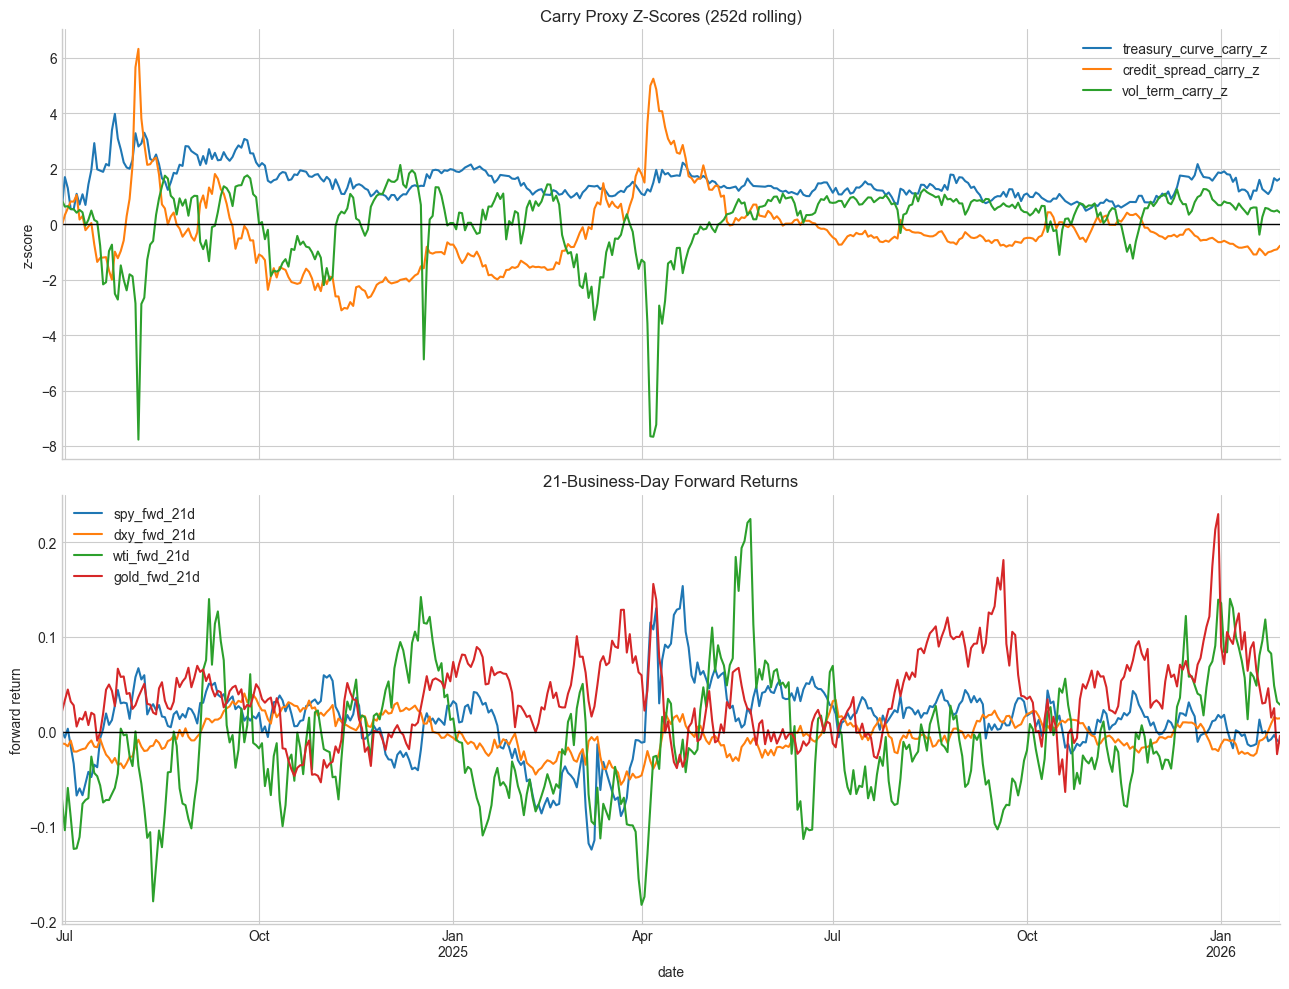

    bucket  mean_fwd_return                  signal       target
0        0        -0.000115  treasury_curve_carry_z  spy_fwd_21d
1        1        -0.005647  treasury_curve_carry_z  spy_fwd_21d
2        2         0.011572  treasury_curve_carry_z  spy_fwd_21d
3        3         0.025550  treasury_curve_carry_z  spy_fwd_21d
4        4         0.027710  treasury_curve_carry_z  spy_fwd_21d
5        0        -0.002574  treasury_curve_carry_z  dxy_fwd_21d
6        1        -0.009129  treasury_curve_carry_z  dxy_fwd_21d
7        2        -0.007655  treasury_curve_carry_z  dxy_fwd_21d
8        3         0.002806  treasury_curve_carry_z  dxy_fwd_21d
9        4        -0.000889  treasury_curve_carry_z  dxy_fwd_21d
10       0        -0.029260  treasury_curve_carry_z  wti_fwd_21d
11       1        -0.015237  treasury_curve_carry_z  wti_fwd_21d

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

carry_panel[["treasury_curve_carry_z", "credit_spread_carry_z", "vol_term_carry_z"]].plot(
    ax=axes[0], title="Carry Proxy Z-Scores (252d rolling)"
)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_ylabel("z-score")

carry_panel[["spy_fwd_21d", "dxy_fwd_21d", "wti_fwd_21d", "gold_fwd_21d"]].plot(
    ax=axes[1], title="21-Business-Day Forward Returns"
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_ylabel("forward return")

plt.tight_layout()
plt.show()

carry_panel.to_csv(CARRY_PANEL_CSV)
summary_df.to_csv(SUMMARY_CSV, index=False)

print("Saved carry panel to", CARRY_PANEL_CSV)
print("Saved bucket summary to", SUMMARY_CSV)
summary_df.head(12)